# Unit 9 Artefact 1: Reproducing Andrade et al.'s DRaaS Availability Model

Ian Stevens, Security and Risk Management, Unit 9.

Andrade et al. (2017) model a Disaster-Recovery-as-a-Service (DRaaS) solution with stochastic Petri nets (SPNs). A primary data centre runs a load balancer, five web server VMs (three active, two hot standby, with auto-scaling) and a database VM. A disaster recovery cloud holds a load balancer, three hot-standby web servers and a hot-standby database, and takes over when a disaster strikes the primary site. They solved the SPN in the Mercury tool for three parameter settings (very high, high and medium availability: VHA, HA and MA), with disaster recovery (D/R) enabled and disabled, and reported availability, downtime, downtime cost, lost transactions, RTO and a sensitivity ranking.

Mercury is not freely available, so this notebook translates the SPN into the continuous-time Markov chain (CTMC) it generates and solves that directly. As in Unit 8, the aim is to test whether the published numbers can be reproduced from the published inputs, and what they mean for a small business choosing a recovery solution.

**Sources:** all inputs are from Table 3 of the paper, the model structure from Section 5 and Tables 1, 2 and 4, and the targets from Table 5, Section 6.2 and Table 6.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad

pd.set_option("display.width", 140)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e"
SETTINGS = ["VHA", "HA", "MA"]

## 1. Inputs as printed in Table 3

All values are mean times in hours, so each transition rate is 1 / value.

In [2]:
TABLE3 = {  # parameter: (VHA, HA, MA), hours
    "DCdis": (21915, 17532, 13149), "DCdisRep": (8, 12, 16),
    "DCfail": (13149, 8766, 4383),  "DCrep": (6, 4, 2),
    "LB1fail": (13149, 8766, 4383), "LB1rep": (6, 4, 2),
    "WEB1fail": (2922, 2199, 1461), "WEB1rep": (1, 2, 3),
    "WEB1scUp": (0.033, 0.083, 0.133), "WEB1scDown": (0.033, 0.083, 0.133),
    "DB1fail": (2922, 2199, 1461),  "DB1rep": (1, 2, 3),
    "CSfail": (13149, 8766, 4383),  "CSrep": (6, 4, 2),
    "LB2fail": (13149, 8766, 4383), "LB2rep": (6, 4, 2),
    "WEB2fail": (5844, 4383, 2922), "WEB2hotfail": (2922, 2199, 1461), "WEB2rep": (1, 2, 3),
    "WEB2fover": (0.033, 0.083, 0.133), "WEB2fback": (0.033, 0.083, 0.133),
    "DB2fail": (5844, 4383, 2922),  "DB2hotfail": (2922, 2199, 1461), "DB2rep": (1, 2, 3),
    "DB2fover": (0.033, 0.083, 0.133), "DB2fback": (0.033, 0.083, 0.133),
}
# Published Table 5
PUB = pd.DataFrame({
    "A_on":  [0.999038990, 0.997220208, 0.992429006],
    "A_off": [0.998513995, 0.996144920, 0.990448887],
    "down_on":  [8.42, 24.37, 66.37], "down_off": [13.02, 33.80, 83.72],
    "Dcost_on": [57697.45, 166894.09, 454549.87], "Dcost_off": [89217.25, 231452.57, 573432.91],
    "Lq_on": [8.41845, 24.35098, 66.32191], "Lq_off": [13.01740, 33.77050, 83.66775],
}, index=SETTINGS)

def params(i, swap_repairs=False):
    p = {k: v[i] for k, v in TABLE3.items()}
    if swap_repairs:   # read the four repair rows in the reverse column order (tested in section 3)
        for k in ["DCrep", "LB1rep", "CSrep", "LB2rep"]:
            p[k] = TABLE3[k][2 - i]
    return p

print(pd.DataFrame(TABLE3, index=SETTINGS).T.to_string())

                   VHA         HA         MA
DCdis        21915.000  17532.000  13149.000
DCdisRep         8.000     12.000     16.000
DCfail       13149.000   8766.000   4383.000
DCrep            6.000      4.000      2.000
LB1fail      13149.000   8766.000   4383.000
LB1rep           6.000      4.000      2.000
WEB1fail      2922.000   2199.000   1461.000
WEB1rep          1.000      2.000      3.000
WEB1scUp         0.033      0.083      0.133
WEB1scDown       0.033      0.083      0.133
DB1fail       2922.000   2199.000   1461.000
DB1rep           1.000      2.000      3.000
CSfail       13149.000   8766.000   4383.000
CSrep            6.000      4.000      2.000
LB2fail      13149.000   8766.000   4383.000
LB2rep           6.000      4.000      2.000
WEB2fail      5844.000   4383.000   2922.000
WEB2hotfail   2922.000   2199.000   1461.000
WEB2rep          1.000      2.000      3.000
WEB2fover        0.033      0.083      0.133
WEB2fback        0.033      0.083      0.133
DB2fail   

One thing stands out before any modelling. The authors say the VHA setting represents conditions such as 'the existence of spare components on-site for speeding up the repairing activities'. That holds for the web and database servers, whose repair times rise from 1 h (VHA) to 3 h (MA). But the repair times of the data centre, both load balancers and the cloud server run the other way, 6 h for VHA and 2 h for MA, so the 'very high availability' setting has the slowest repairs. Section 3 tests whether the results were calculated with the table as printed.

## 2. Translating the SPN into a CTMC

Each marking of the SPN becomes a state: data centre (up, transient failure, disaster), primary load balancer and database (up/down), the five primary web server tokens split between up, hot standby and down, the cloud server and cloud load balancer (up/down), the three cloud web server tokens split between hot standby, failed over (up) and down, and the cloud database (hot, up, down).

The rules follow Section 5 and Tables 1, 2 and 4:

* every timed transition is exponential with **single-server semantics** (the paper states this explicitly), so three active web servers fail at rate 1/MTTF in total, and repairs and failovers move one token at a time;
* when the data centre is down, immediate transitions take every primary VM down, and their repair is disabled until the data centre is back (guards `G_WEB1rep`, `G_DB1rep`, `G_LB1rep`); the same applies to the cloud VMs and the cloud server;
* the primary scales up when fewer than three web servers are active and scales down when more than three are;
* failover is enabled only while the data centre is in the **disaster** state, and failback only when the whole primary infrastructure is working again;
* the service is available when (LB1 up AND at least 3 primary web servers up AND DB1 up) OR, with D/R enabled, (LB2 up AND 3 cloud web servers failed over AND DB2 failed over) (Table 4).

The two semantic choices that the text leaves least clear (single or infinite server, and whether VMs need their own repair after a data centre outage) are left as switches so that every combination can be tested.

In [3]:
FIELDS = ["dc", "lb1", "db1", "wu", "wh", "wd", "cs", "lb2", "u2", "h2", "d2", "db2"]

def build(p, dr=True, server="single", vm_repair_after_dc=True):
    k = (lambda n: n) if server == "infinite" else (lambda n: 1)

    def norm(s):  # immediate transitions
        s = dict(zip(FIELDS, s))
        if s["dc"] != "U" and vm_repair_after_dc:
            s.update(lb1=0, db1=0, wd=s["wu"] + s["wh"] + s["wd"], wu=0, wh=0)
        if s["cs"] == 0:
            s.update(lb2=0, d2=s["u2"] + s["h2"] + s["d2"], u2=0, h2=0, db2="D")
        return tuple(s[f] for f in FIELDS)

    start = norm(("U", 1, 1, 3, 2, 0, 1, 1, 0, 3 if dr else 0, 0, "H"))
    idx, states, trans, todo = {start: 0}, [start], [], [start]
    while todo:
        s = todo.pop(); d = dict(zip(FIELDS, s)); out = []
        mk = lambda **kw: tuple({**d, **kw}[f] for f in FIELDS)
        up = d["dc"] == "U"
        if up:
            out += [(mk(dc="D"), 1 / p["DCfail"]), (mk(dc="X"), 1 / p["DCdis"])]
        else:
            out.append((mk(dc="U"), 1 / (p["DCrep"] if d["dc"] == "D" else p["DCdisRep"])))
        if up:
            out.append((mk(lb1=1 - d["lb1"]), 1 / p["LB1fail" if d["lb1"] else "LB1rep"]))
            out.append((mk(db1=1 - d["db1"]), 1 / p["DB1fail" if d["db1"] else "DB1rep"]))
            if d["wu"] > 0: out.append((mk(wu=d["wu"] - 1, wd=d["wd"] + 1), k(d["wu"]) / p["WEB1fail"]))
            if d["wd"] > 0: out.append((mk(wu=d["wu"] + 1, wd=d["wd"] - 1), k(d["wd"]) / p["WEB1rep"]))
            if d["wu"] < 3 and d["wh"] > 0: out.append((mk(wu=d["wu"] + 1, wh=d["wh"] - 1), 1 / p["WEB1scUp"]))
            if d["wu"] > 3: out.append((mk(wu=d["wu"] - 1, wh=d["wh"] + 1), 1 / p["WEB1scDown"]))
        if dr:
            out.append((mk(cs=1 - d["cs"]), 1 / p["CSfail" if d["cs"] else "CSrep"]))
            if d["cs"]:
                out.append((mk(lb2=1 - d["lb2"]), 1 / p["LB2fail" if d["lb2"] else "LB2rep"]))
                prim_ok = up and d["wu"] == 3 and d["db1"] == 1 and d["lb1"] == 1
                h2, u2, d2 = d["h2"], d["u2"], d["d2"]
                if h2: out.append((mk(h2=h2 - 1, d2=d2 + 1), k(h2) / p["WEB2hotfail"]))
                if h2 and d["dc"] == "X": out.append((mk(h2=h2 - 1, u2=u2 + 1), k(h2) / p["WEB2fover"]))
                if u2 and prim_ok: out.append((mk(u2=u2 - 1, h2=h2 + 1), k(u2) / p["WEB2fback"]))
                if u2: out.append((mk(u2=u2 - 1, d2=d2 + 1), k(u2) / p["WEB2fail"]))
                if d2: out.append((mk(d2=d2 - 1, h2=h2 + 1), k(d2) / p["WEB2rep"]))
                db2 = d["db2"]
                if db2 == "H":
                    out.append((mk(db2="D"), 1 / p["DB2hotfail"]))
                    if d["dc"] == "X": out.append((mk(db2="U"), 1 / p["DB2fover"]))
                elif db2 == "U":
                    out.append((mk(db2="D"), 1 / p["DB2fail"]))
                    if prim_ok: out.append((mk(db2="H"), 1 / p["DB2fback"]))
                else:
                    out.append((mk(db2="H"), 1 / p["DB2rep"]))
        for t, r in out:
            t = norm(t)
            if t == s: continue
            if t not in idx:
                idx[t] = len(states); states.append(t); todo.append(t)
            trans.append((idx[s], idx[t], r))
    Q = lil_matrix((len(states), len(states)))
    for i, j, r in trans:
        Q[i, j] += r; Q[i, i] -= r
    return states, csr_matrix(Q)

def available(s, dr=True):
    d = dict(zip(FIELDS, s))
    prim = d["dc"] == "U" and d["lb1"] == 1 and d["wu"] >= 3 and d["db1"] == 1
    cloud = dr and d["lb2"] == 1 and d["u2"] >= 3 and d["db2"] == "U"
    return prim or cloud

def steady_state(Q):
    n = Q.shape[0]; A = Q.T.tolil(); A[0, :] = 1; b = np.zeros(n); b[0] = 1
    return spsolve(csr_matrix(A), b)

def availability(p, dr=True, **kw):
    states, Q = build(p, dr, **kw)
    pi = steady_state(Q)
    return float(sum(pi[i] for i, s in enumerate(states) if available(s, dr)))

states, Q = build(params(1))
print(f"Reachable states: {len(states):,} with D/R enabled, {len(build(params(1), dr=False)[0])} without")

Reachable states: 3,782 with D/R enabled, 62 without


## 3. Does Table 5 reproduce?

Every combination of the two semantic switches is run with the table as printed and with the four repair rows (DCrep, LB1rep, CSrep, LB2rep) read in reverse column order.

In [4]:
rows = []
for swap in [False, True]:
    for server in ["single", "infinite"]:
        for vr in [True, False]:
            for i, s in enumerate(SETTINGS):
                p = params(i, swap)
                on, off = availability(p, True, server=server, vm_repair_after_dc=vr), availability(p, False, server=server, vm_repair_after_dc=vr)
                rows.append(dict(repairs="reversed" if swap else "as printed", server=server, vm_repair=vr, setting=s,
                                 A_on=on, A_off=off,
                                 err_on_h=(PUB.loc[s, "A_on"] - on) * 8760, err_off_h=(PUB.loc[s, "A_off"] - off) * 8760))
grid = pd.DataFrame(rows)
summary = (grid.assign(abs_err=lambda g: (g.err_on_h.abs() + g.err_off_h.abs()) / 2)
               .groupby(["repairs", "server", "vm_repair"]).abs_err.agg(["mean", "max"]).round(2)
               .rename(columns={"mean": "mean |error| (h/yr)", "max": "max |error| (h/yr)"}))
print(summary.sort_values("mean |error| (h/yr)").to_string())

                               mean |error| (h/yr)  max |error| (h/yr)
repairs    server   vm_repair                                         
reversed   single   True                      0.68                1.33
           infinite True                      4.26                8.64
as printed single   True                      9.73               20.76
reversed   infinite False                    12.59               25.48
           single   False                    13.35               26.96
as printed infinite True                     13.97               31.31
                    False                    17.56               41.37
           single   False                    18.19               42.86


In [5]:
best = grid[(grid.repairs == "reversed") & (grid.server == "single") & (grid.vm_repair)].set_index("setting")
printed = grid[(grid.repairs == "as printed") & (grid.server == "single") & (grid.vm_repair)].set_index("setting")
cmp = pd.DataFrame({
    "published, D/R on": PUB.A_on, "as printed": printed.A_on, "repairs reversed": best.A_on,
    "published, D/R off": PUB.A_off, "as printed ": printed.A_off, "repairs reversed ": best.A_off,
})
print(cmp.to_string(float_format=lambda x: f"{x:.6f}"))
print("\nDowntime (h/yr), repairs reversed vs published:")
print(pd.DataFrame({"D/R on": (1 - best.A_on) * 8760, "published on": PUB.down_on,
                    "D/R off": (1 - best.A_off) * 8760, "published off": PUB.down_off}).round(2).to_string())

     published, D/R on  as printed  repairs reversed  published, D/R off  as printed   repairs reversed 
VHA           0.999039    0.998209          0.999057            0.998514     0.997543           0.998532
HA            0.997220    0.997283          0.997283            0.996145     0.996208           0.996208
MA            0.992429    0.994746          0.992581            0.990449     0.992873           0.990600

Downtime (h/yr), repairs reversed vs published:
     D/R on  published on  D/R off  published off
VHA    8.26          8.42    12.86          13.02
HA    23.80         24.37    33.22          33.80
MA    64.99         66.37    82.34          83.72


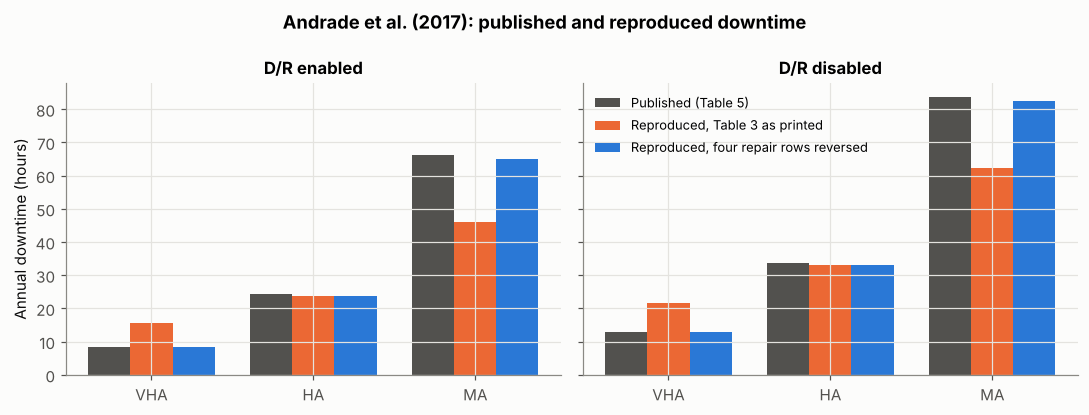

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
x = np.arange(3); w = 0.26
for a, col, title in [(ax[0], "on", "D/R enabled"), (ax[1], "off", "D/R disabled")]:
    pubd = (1 - PUB[f"A_{col}"]) * 8760
    a.bar(x - w, pubd, w, color=INK, label="Published (Table 5)")
    a.bar(x, (1 - printed[f"A_{col}"]) * 8760, w, color=ORANGE, label="Reproduced, Table 3 as printed")
    a.bar(x + w, (1 - best[f"A_{col}"]) * 8760, w, color=BLUE, label="Reproduced, four repair rows reversed")
    a.set_xticks(x, SETTINGS); a.set_title(title)
ax[0].set_ylabel("Annual downtime (hours)")
ax[1].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.suptitle("Andrade et al. (2017): published and reproduced downtime", fontweight="bold")
fig.tight_layout()
fig.savefig("figures/u9_reproduction.png", dpi=160, bbox_inches="tight")

With Table 3 as printed, VHA comes out *worse* than published and MA *better*, by up to 20 hours a year. Reading the four repair rows the other way round (VHA 2 h, MA 6 h), with single-server semantics and VM repair after a data centre outage as the paper describes, reproduces all six availabilities to within 1.4 hours of downtime a year (2% or less). HA, whose values are the same either way, matches as printed. The likeliest explanation is that those four rows were printed in the wrong column order, and the results were calculated with the values the text implies. The remaining gap (my downtime is 1% to 2% lower in every case) may come from details of the Mercury model that are not in the paper.

## 4. Checking the derived figures in Table 5 and Section 6.1

In [7]:
t = PUB.copy()
t["reduction_in_downtime"] = 1 - t.down_on / t.down_off
t["ratio_on_off"] = t.down_on / t.down_off
t["Lq_recalc_on"] = (1 - t.A_on) * 8760 * 1000       # Eq. (7), lambda = 1000 transactions per hour
t["Dcost_hours_implied"] = t.Dcost_on / 6849
print(t[["down_on", "down_off", "reduction_in_downtime", "ratio_on_off", "Lq_on", "Lq_recalc_on", "Dcost_hours_implied"]].round(3).to_string())
print(f"\nRevenue per high-revenue hour = $1,000,000 / (365 x 4) = ${1_000_000 / (365 * 4):,.2f}")
print(f"Average revenue per hour      = $1,000,000 / 8,760    = ${1_000_000 / 8760:,.2f}")

     down_on  down_off  reduction_in_downtime  ratio_on_off   Lq_on  Lq_recalc_on  Dcost_hours_implied
VHA     8.42     13.02                  0.353         0.647   8.418      8418.448                8.424
HA     24.37     33.80                  0.279         0.721  24.351     24350.978               24.368
MA     66.37     83.72                  0.207         0.793  66.322     66321.907               66.367

Revenue per high-revenue hour = $1,000,000 / (365 x 4) = $684.93
Average revenue per hour      = $1,000,000 / 8,760    = $114.16


Three of the derived figures do not follow from the paper's own inputs:

1. **The size of the improvement is overstated.** The text says D/R cuts HA downtime by 'more than 72%' and lost requests by 64%, 72% and 79%. Those are the ratios of downtime *with* D/R to downtime *without* it. The reductions are 35%, 28% and 21%.
2. **Lost transactions are 1,000 times too small.** Eq. (7) with T = 8,760 h and λ = 1,000 transactions per hour gives 8,418 lost transactions for VHA with D/R, not 8.42. The Lq column equals the downtime in hours, so λ appears to have been left at 1.
3. **The hourly cost of downtime looks ten times too high.** The paper uses $6,849 per hour for a business with $1,000,000 of annual revenue, all online, with 4 high-revenue hours a day. Revenue per high-revenue hour is $1,000,000 / (365 × 4) = $684.93, which is the published figure divided by ten. (The cost column also uses an 8,766-hour year, while Lq uses 8,760.) At $6,849 an hour the MA system without D/R would lose $573,433 a year, 57% of total revenue.

     downtime avoided (h/yr)  saving at $6,849/h  saving at $684.93/h  saving at $114.16/h (average hour)  break-even $/h (public cloud DRaaS)
VHA                      5.0             31505.0               3151.0                               525.0                               2682.0
HA                       9.0             64586.0               6459.0                              1076.0                               1308.0
MA                      17.0            118830.0              11884.0                              1981.0                                711.0


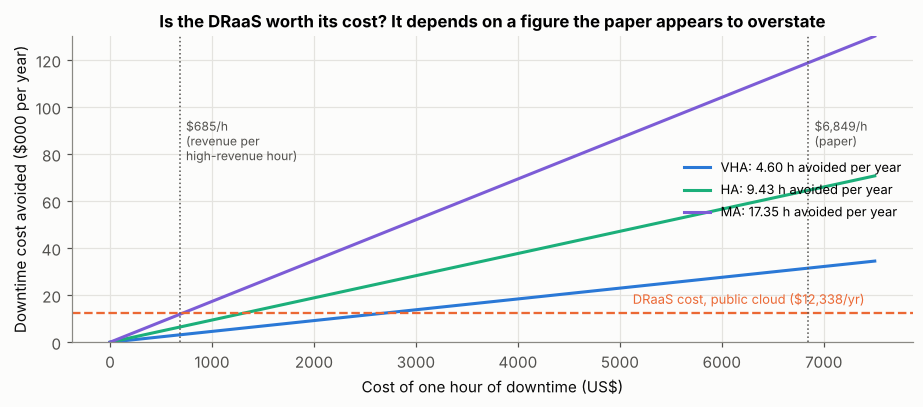

In [8]:
DRAAS_PUBLIC, DRAAS_PRIVATE = 12_337.92, 16_185.60    # US$ per year, Section 6.1
saved_h = PUB.down_off - PUB.down_on
cb = pd.DataFrame({
    "downtime avoided (h/yr)": saved_h,
    "saving at $6,849/h": saved_h * 6849,
    "saving at $684.93/h": saved_h * 684.93,
    "saving at $114.16/h (average hour)": saved_h * 1_000_000 / 8760,
    "break-even $/h (public cloud DRaaS)": DRAAS_PUBLIC / saved_h,
}).round(0)
print(cb.to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
rates = np.linspace(0, 7500, 300)
for s, c in zip(SETTINGS, [BLUE, AQUA, VIOLET]):
    ax.plot(rates, saved_h[s] * rates / 1000, color=c, label=f"{s}: {saved_h[s]:.2f} h avoided per year")
ax.axhline(DRAAS_PUBLIC / 1000, color=ORANGE, ls="--", lw=1.5)
ax.text(7400, DRAAS_PUBLIC / 1000 + 4, "DRaaS cost, public cloud ($12,338/yr)", color=ORANGE, ha="right", fontsize=8.5)
for r, lab in [(684.93, "$685/h\n(revenue per\nhigh-revenue hour)"), (6849, "$6,849/h\n(paper)")]:
    ax.axvline(r, color=INK, lw=1, ls=":")
    ax.text(r + 60, 95, lab, fontsize=8, color=INK, va="top")
ax.set_xlabel("Cost of one hour of downtime (US$)"); ax.set_ylabel("Downtime cost avoided ($000 per year)")
ax.set_ylim(0, 130); ax.legend(frameon=False, fontsize=8.5, loc="center right")
ax.set_title("Is the DRaaS worth its cost? It depends on a figure the paper appears to overstate")
fig.tight_layout()
fig.savefig("figures/u9_breakeven.png", dpi=160, bbox_inches="tight")

At the paper's $6,849 an hour, D/R pays for itself in every setting. At $684.93 an hour it pays for itself in none of them, although MA comes close, and the break-even cost is between about $700 and $2,700 an hour. The paper's conclusion that DRaaS is 'an acceptable cost' therefore depends on the one input that does not follow from its own description of the business.

## 5. What does the published RTO measure?

Section 6.2 reports mean RTOs of 6.36, 16.26 and 27.65 minutes and concludes that only VHA meets a 15-minute RTO. Three readings of 'recovery' are compared, starting from the moment a disaster strikes a fully working system:

* **Failover only:** the three cloud web servers are activated one at a time (single-server semantics) while the database fails over in parallel, so the time is the larger of an Erlang(3) and an exponential delay.
* **Full model, service restored:** the mean time until the service is available again in the full CTMC, including the rare paths where something else fails during failover.
* **Primary restored:** the guard of the paper's own RTO model (Table 2), which waits until the primary data centre and all its VMs are working again.

In [9]:
def failover_cdf(t, m):
    lam = 1 / m
    erl = 1 - np.exp(-lam * t) * (1 + lam * t + (lam * t) ** 2 / 2)
    return erl * (1 - np.exp(-lam * t))

def mtta(p, target, start):
    states, Q = build(p)
    idx = {s: i for i, s in enumerate(states)}
    T = {i for i, s in enumerate(states) if target(s)}
    keep = [i for i in range(len(states)) if i not in T]
    m = spsolve(csr_matrix(-Q[keep][:, keep]), np.ones(len(keep)))
    return m[keep.index(idx[start])]

disaster_start = ("X", 0, 0, 0, 0, 5, 1, 1, 0, 3, 0, "H")
primary_ok = lambda s: s[0] == "U" and s[1] == 1 and s[2] == 1 and s[3] >= 3
rto = []
for i, s in enumerate(SETTINGS):
    p = params(i, swap_repairs=True); m = p["WEB2fover"] * 60
    rto.append(dict(setting=s,
        published_min=[6.36, 16.26, 27.65][i],
        failover_only_min=quad(lambda t: 1 - failover_cdf(t, m), 0, np.inf)[0],
        full_model_min=mtta(p, available, disaster_start) * 60,
        primary_restored_h=mtta(p, primary_ok, disaster_start),
        p_failover_over_15min=1 - failover_cdf(15, m)))
rto = pd.DataFrame(rto).set_index("setting")
print(rto.round(3).to_string())

         published_min  failover_only_min  full_model_min  primary_restored_h  p_failover_over_15min
setting                                                                                             
VHA               6.36              6.188           8.965              11.678                  0.020
HA               16.26             15.562          24.821              19.367                  0.449
MA               27.65             24.938          41.735              27.086                  0.754


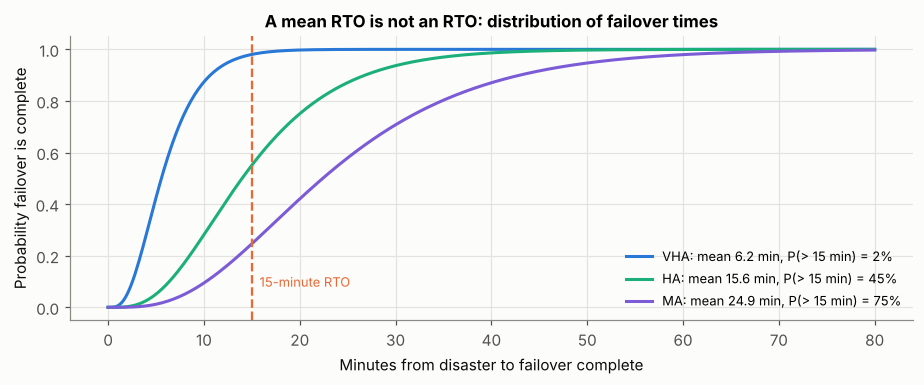

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
t = np.linspace(0, 80, 400)
for (s, r), c in zip(rto.iterrows(), [BLUE, AQUA, VIOLET]):
    m = params(SETTINGS.index(s))["WEB2fover"] * 60
    ax.plot(t, failover_cdf(t, m), color=c, label=f"{s}: mean {r.failover_only_min:.1f} min, P(> 15 min) = {r.p_failover_over_15min:.0%}")
ax.axvline(15, color=ORANGE, ls="--", lw=1.5); ax.text(15.8, 0.08, "15-minute RTO", color=ORANGE, fontsize=8.5)
ax.set_xlabel("Minutes from disaster to failover complete"); ax.set_ylabel("Probability failover is complete")
ax.set_title("A mean RTO is not an RTO: distribution of failover times")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
fig.tight_layout()
fig.savefig("figures/u9_rto.png", dpi=160, bbox_inches="tight")

The published RTOs are close to the failover-only times (6.2, 15.6 and 24.9 minutes), so they measure how long it takes the cloud to take over, not the time to restore the primary site, which by the paper's own Table 2 guard is 12 to 27 hours. Two further points matter for anyone using these figures. First, an RTO is a limit, so comparing it with a *mean* is a category error: under HA, whose mean misses the target, about 55% of failovers would still finish within 15 minutes, and under VHA, whose mean meets it, about 1 in 50 would not. Second, failover is only triggered by a disaster. If the data centre comes back mid-failover, the guards stop the failover and service waits for the primary VMs to be repaired, which is why the full-model mean is longer.

## 6. Sensitivity ranking (Table 6)

The paper ranks parameters with the percentage difference index S = (max A − min A) / max A, varying one parameter over its range with the others at HA values. Fig. 9 shows the ranges, which run from the MA to the VHA value. The ranking is repeated here with D/R enabled, as in the paper, and with D/R disabled.

In [11]:
def sens(dr):
    base = params(1, swap_repairs=True); out = {}
    for k in TABLE3:
        if not dr and ("2" in k or k.startswith("CS")):   # cloud parameters do not exist without D/R
            continue
        vals = sorted(set(TABLE3[k]))
        a = [availability({**base, k: v}, dr) for v in (vals[0], vals[-1])]
        out[k] = (max(a) - min(a)) / max(a)
    return pd.Series(out).sort_values(ascending=False)

s_on, s_off = sens(True), sens(False)
pub_top = ["DCfail", "DB1rep", "LB1rep", "DB1fail", "LB1fail", "WEB1rep", "DCrep", "WEB1scUp", "WEB1fail", "WEB1scDown"]
rank = pd.DataFrame({"S, D/R on": s_on, "rank on": s_on.rank(ascending=False).astype(int),
                     "S, D/R off": s_off, "rank off": s_off.rank(ascending=False)})
rank["published rank"] = [pub_top.index(k) + 1 if k in pub_top else None for k in rank.index]
print(rank.sort_values("rank on").round(6).to_string())

             S, D/R on  rank on  S, D/R off  rank off  published rank
DCfail        0.001722        1    0.001724       1.0             1.0
DB1rep        0.000960        2    0.000987       2.0             2.0
LB1rep        0.000709        3    0.000831       3.0             3.0
DB1fail       0.000683        4    0.000683       5.0             4.0
LB1fail       0.000607        5    0.000608       6.0             5.0
WEB1rep       0.000516        6    0.000764       4.0             6.0
DCrep         0.000455        7    0.000456       9.0             7.0
WEB1scUp      0.000042        8    0.000042      10.0             8.0
WEB1fail      0.000028        9    0.000028      11.0             9.0
WEB2fover     0.000024       10         NaN       NaN             NaN
DCdis         0.000013       11    0.000588       7.0             NaN
DCdisRep      0.000006       12    0.000456       8.0             NaN
DB2fover      0.000003       13         NaN       NaN             NaN
CSfail        0.0000

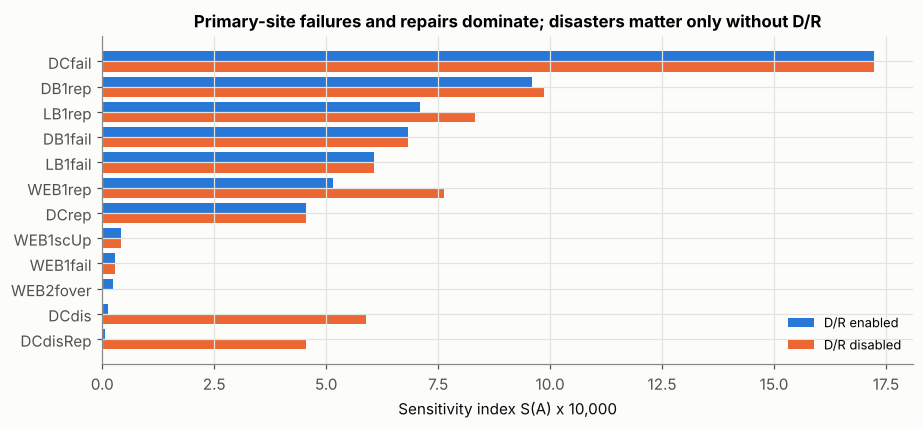

In [12]:
top = s_on.head(12)
fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(top))[::-1]
ax.barh(y + 0.2, top.values * 1e4, 0.4, color=BLUE, label="D/R enabled")
ax.barh(y - 0.2, [s_off.get(k, 0) * 1e4 for k in top.index], 0.4, color=ORANGE, label="D/R disabled")
ax.set_yticks(y, top.index); ax.set_xlabel("Sensitivity index S(A) x 10,000")
ax.set_title("Primary-site failures and repairs dominate; disasters matter only without D/R")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
fig.tight_layout()
fig.savefig("figures/u9_sensitivity.png", dpi=160, bbox_inches="tight")

The reproduction is close. The top nine parameters come out in exactly the published order, and their indices agree with Table 6 to within about 3% (for example 0.000683 against 0.00068267 for DB1fail, and 0.000455 against 0.00045550 for DCrep). The one clear difference is WEB1scDown, which has no effect in my model because a fourth active web server cannot make the service unavailable. The ranking keeps the paper's main message: the failure and repair rates of the primary data centre and its VMs dominate, and the disaster recovery components barely matter once D/R is in place. Turning D/R off shows the other side. The disaster parameters (DCdis, DCdisRep) move up the ranking because nothing covers a disaster any more, but even then the everyday failures of the primary site cost more availability. For a small business this is the more useful finding: a DR solution protects against the rare event, and most of the downtime comes from ordinary faults that it was never designed to cover.

## 7. Summary

| Check | Result |
|---|---|
| Availability, Table 3 as printed | VHA and MA do not reproduce (up to about 20 h/yr out); HA does |
| Availability, four repair rows reversed | All six values within 1.4 h/yr (2% or less) |
| 'More than 72%' and 64/72/79% reductions | Ratios, not reductions; real reductions 35%, 28%, 21% |
| Lost transactions, Eq. (7) | Published values 1,000 times too small |
| Hourly downtime cost | $6,849 is ten times $1,000,000 / (365 × 4) |
| Cost case for DRaaS | Holds at $6,849/h; fails in all settings at $685/h |
| Published RTO | Mean failover time, not time to restore the primary; a mean compared with a limit |
| Sensitivity ranking | Top nine in the published order, indices within about 3%; primary-site faults dominate |

The model itself is sound and useful. The paper's arithmetic around it is not, and the error that matters most for a decision, the hourly cost of downtime, is the one that turns a marginal investment into an obvious one.